### Set autoreloading
This extension will automatically update with any changes to packages in real time

In [1]:
%load_ext autoreload
%autoreload 2

### Import packages
We'll need the `nugraph` and `pynuml` packages imported in order to plot, and `torch` for some tensor operations later on

In [2]:
import os
from pathlib import Path
import nugraph as ng
import pynuml
import torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go

### Set model and data to use

This allows the user to switch out different model architectures and datasets

In [34]:
DATA_PATH = "/net/projects2/fermi2526/data/nugraph3-dsi.optical.fix.renamed.gnn.h5"
Data = ng.data.NuGraphDataModule
Model = ng.models.NuGraph3

### Configure data module
Declare a data module. If you're working on a standard cluster, the data file location should be configured automatically. If not, you'll need to configure it manually.

In [35]:
nudata = Data(model=Model, data_path=DATA_PATH, num_workers=0)

### Configure network
In order to test a trained model, we instantiate it using a checkpoint file. These are produced during training, so if you've trained a model, there should be an associated checkpoint in your output directory that you can pass here.

In [36]:
ckpt = os.environ.get("NUGRAPH_CKPT", "/home/vihaan/NuGraph/logs/optical-main/test-optical-pmt/checkpoints/epoch=49-step=310400.ckpt").strip()
if ckpt and Path(ckpt).exists():
    model = Model.load_from_checkpoint(ckpt, map_location="cpu", strict=False)
    model.freeze()

    # ensure dataset feature extension matches checkpoint expectations (avoids dimension mismatches)
    expected = int(getattr(model, "in_features", 0) or model.hparams.get("in_features", 0) or 0)
    sample = nudata.train_dataset[0]["hit"].x.size(1)
    if expected and sample != expected:
        if sample + 4 == expected: # change number based on expected
            print(f"Rebuilding data module with featext=True ({sample} -> {expected} features)")
            nudata = Data(model=Model, data_path=DATA_PATH,
                         num_workers=0, featext=True)
        else:
            print(f"Warning: checkpoint expects {expected} input features, but data has {sample}.")
else:
    model = None
    print("No checkpoint provided. Set NUGRAPH_CKPT to enable predictions.")

/net/projects2/fermi2526/conda/nugraph-25-10/lib/python3.13/site-packages/pytorch_lightning/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['optical_net.sp_max_degree_param', 'optical_net.ophit_to_ophit.edge_net.0.weight', 'optical_net.ophit_to_ophit.edge_net.0.bias', 'optical_net.ophit_to_ophit.net.0.weight', 'optical_net.ophit_to_ophit.net.0.bias', 'optical_net.ophit_to_ophit.net.2.weight', 'optical_net.ophit_to_ophit.net.2.bias']


Rebuilding data module with featext=True (8 -> 12 features)


## Configure plotting utility
Instantiate the **pynuml** utility for plotting graph objects, which will do the heavy lifting for us here!

In [37]:
plot = pynuml.plot.GraphPlot(planes=nudata.planes,
                             classes=nudata.semantic_classes)

## Plot ground truth labels

### Iterable dataset

First we define an iterator over the test dataset:

In [38]:
test_iter = iter(nudata.test_dataset)

### Retrieve the next graph

This block retrieves a graph from the testing dataset, and passes it through the trained model. Since we defined `test_iter` as an iterator over the dataset, the following block can be executed multiple times, and each time it's executed, it will step to the next graph in the dataset.

In [41]:
data = next(test_iter)
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'

# cache sumPE before model.step mutates node features into embeddings
if data['pmt'].x.size(1) > 3:
    pmt_sumpe = data['pmt'].x[:, 3].detach().cpu()
else:
    pmt_sumpe = torch.zeros(data['pmt'].num_nodes)

if model is not None:
    model.step(data)

### Plot a single graph

We can now use pynuml's plotting utilities to plot the graph as a figure. Each time you call the above block to retrieve a new graph, you can then re-execute the plotting blocks to re-plot with the new graph.

In [14]:
# true semantic labels

plot.plot(data, target='semantic', how='pred', filter='none')
plot.plot(data, target='semantic', how='true', filter='none')

plot.plot(data, target='semantic', how='pred', filter='show')
plot.plot(data, target='semantic', how='true', filter='show')

fig = plot.plot(data, target='semantic', how='true')
fig

FigureWidget({
    'data': [{'customdata': array([['background', '-1', 0.0015380342956632376, 'diffuse', '-1'],
                                   ['background', '-1', 0.10767577588558197, 'muon', '-1'],
                                   ['background', '-1', 0.07251835614442825, 'diffuse', '-1'],
                                   ['background', '-1', 0.03918131813406944, 'michel', '-1'],
                                   ['background', '-1', 0.025956496596336365, 'diffuse', '-1'],
                                   ['background', '-1', 0.10272743552923203, 'diffuse', '-1'],
                                   ['background', '-1', 0.15223145484924316, 'diffuse', '-1'],
                                   ['background', '-1', 0.0347692146897316, 'michel', '-1'],
                                   ['background', '-1', 0.06006171926856041, 'diffuse', '-1'],
                                   ['background', '-1', 0.4293491244316101, 'michel', '-1'],
                                   ['bac

In [15]:
# predicted semantic labels

plot.plot(data, target='semantic', how='pred', filter='none')
plot.plot(data, target='semantic', how='true', filter='none')

plot.plot(data, target='semantic', how='pred', filter='show')
plot.plot(data, target='semantic', how='true', filter='show')

fig = plot.plot(data, target='semantic', how='pred', filter='show') # filter ='none' to see semantic classifications of all points
fig

FigureWidget({
    'data': [{'customdata': array([['background', '-1', 0.0015380342956632376, 'background', '-1'],
                                   ['background', '-1', 0.10767577588558197, 'background', '-1'],
                                   ['background', '-1', 0.07251835614442825, 'background', '-1'],
                                   ...,
                                   ['background', '-1', 0.0347941629588604, 'background', '-1'],
                                   ['background', '-1', 0.04072726145386696, 'background', '-1'],
                                   ['background', '-1', 0.026072772219777107, 'background', '-1']],
                                  shape=(312, 5), dtype=object),
              'hovertemplate': ('semantic prediction=%{customda' ... 'tomdata[4]:.4f}<extra></extra>'),
              'legendgroup': 'background',
              'marker': {'color': 'lightgrey', 'symbol': 'circle'},
              'mode': 'markers',
              'name': 'background',
     

### Plot optical PMT/spacepoint connectivity

This cell visualizes PMT and spacepoint positions in the y-z plane, colors PMTs by sumPE, and overlays PMT-to-spacepoint edges.

PMT-SP edge summary: kept=406, pruned=26, total=432
Learned SP degree cap (soft): 12.000


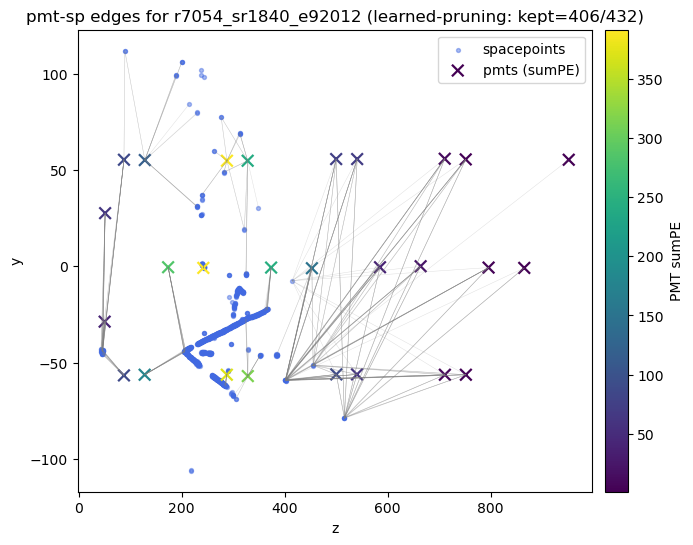

In [42]:
# 2D display showing only post-pruned PMT->SP edges; PMTs colored by sumPE

pmt_pos = data['pmt'].pos.cpu()
sp_pos = data['sp'].pos.cpu()

if 'pmt_sumpe' in locals() and pmt_sumpe.numel() == pmt_pos.size(0):
    pmt_sumpe_plot = pmt_sumpe
elif data['pmt'].x.size(1) > 3:
    pmt_sumpe_plot = data['pmt'].x[:, 3].detach().cpu()
else:
    pmt_sumpe_plot = torch.zeros(pmt_pos.size(0))

sp_y = sp_pos[:, 1] if sp_pos.size(1) > 1 else sp_pos[:, 0]
sp_z = sp_pos[:, 2] if sp_pos.size(1) > 2 else sp_pos[:, -1]
pmt_y = pmt_pos[:, 0]
pmt_z = pmt_pos[:, 1] if pmt_pos.size(1) > 1 else pmt_pos[:, 0]

pmt_sp_edges = data['pmt', 'knn', 'sp'].edge_index
candidate_edges = int(pmt_sp_edges.size(1))

pruning_mode = 'no-pruning-mask'
keep = torch.ones(candidate_edges, dtype=torch.bool, device=pmt_sp_edges.device)
cap_value = None

if (
    model is not None
    and hasattr(model, 'optical_net')
    and getattr(model.optical_net, 'use_pmt_sp_pruning', False)
    and candidate_edges > 0
):
    edge_distance = getattr(data['pmt', 'knn', 'sp'], 'edge_distance', None)
    if edge_distance is None or edge_distance.numel() != candidate_edges:
        ppos = data['pmt'].pos[pmt_sp_edges[0]]
        spos = data['sp'].pos[pmt_sp_edges[1]]
        common_dim = min(ppos.size(-1), spos.size(-1))
        edge_distance = torch.linalg.norm(ppos[:, -common_dim:] - spos[:, -common_dim:], dim=1)

    with torch.no_grad():
        mask = model.optical_net.pmt_sp_pruning_mask(
            data, pmt_sp_edges, edge_distance.float()
        )
    keep = mask > 0.5
    pruning_mode = 'learned-pruning'
    if hasattr(data['sp'], 'pmt_degree_cap') and data['sp'].pmt_degree_cap.numel() > 0:
        cap_value = float(data['sp'].pmt_degree_cap.reshape(-1)[0].item())

kept_edges = pmt_sp_edges[:, keep]
num_kept = int(kept_edges.size(1))
num_pruned = candidate_edges - num_kept

print(f'PMT-SP edge summary: kept={num_kept}, pruned={num_pruned}, total={candidate_edges}')
if cap_value is not None:
    print(f'Learned SP degree cap (soft): {cap_value:.3f}')
else:
    print('Learned SP degree cap (soft): unavailable')

fig, ax = plt.subplots(figsize=(8, 6))
sp_scatter = ax.scatter(
    sp_z, sp_y, s=8, alpha=0.45, color='royalblue', label='spacepoints'
)
pmt_scatter = ax.scatter(
    pmt_z, pmt_y, s=70, c=pmt_sumpe_plot, cmap='viridis', marker='x', linewidths=1.6, label='pmts (sumPE)'
)

pmt_cbar = fig.colorbar(pmt_scatter, ax=ax, pad=0.02)
pmt_cbar.set_label('PMT sumPE')

for src, tgt in kept_edges.t().cpu().tolist():
    y0, z0 = pmt_y[src].item(), pmt_z[src].item()
    y1, z1 = sp_y[tgt].item(), sp_z[tgt].item()
    ax.plot([z0, z1], [y0, y1], color='gray', linewidth=0.35, alpha=0.25)

ax.set_xlabel('z')
ax.set_ylabel('y')
ax.set_title(f'pmt-sp edges for {name} ({pruning_mode}: kept={num_kept}/{candidate_edges})')
ax.legend(loc='best')
plt.show()

### Save plots to disk

We can also use plotly's `write_html` and `write_image` methods to print the figure as an interactive webpage, or in a raster graphics (ie. PNG, JPEG etc) or vector graphics (ie. PDF) format. By default this writes to a `plots` subdirectory – if you're seeing an error that this directory does not exist, simply create one, or change the path to a valid output location!

In [ ]:
fig.write_html(f'plots/evd/{name}_semantic_true.html')
fig.write_image(f'plots/evd/{name}_semantic_true.png')
fig.write_image(f'plots/evd/{name}_semantic_true.pdf')

### (Optional) Select example events

The following blocks will select the representative events from the NuGraph2 paper

### Event 1

Run 5189, subrun 225, event 11300

In [62]:
data = nudata.test_dataset[64]
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'
model.step(data);

### Event 2

Run 6999, subrun 11, event 595

In [63]:
data = nudata.test_dataset[36]
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'
model.step(data);

### Event 3

Run 7048, subrun 177, event 8858

In [64]:
data = nudata.test_dataset[11]
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'
model.step(data);

### Event 4

Run 5459, subrun 94, event 4738

In [65]:
data = nudata.test_dataset[91]
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'
model.step(data);

### Event 5

Run 6780, subrun 200, event 10006

In [66]:
data = nudata.test_dataset[27]
md = data['metadata']
name = f'r{md.run}_sr{md.subrun}_e{md.event}'
model.step(data);

### Plot event displays

Write event displays to disk in PDF format for use in the NuGraph2 paper.

In [ ]:
plot.plot(data, target='filter', how='true', filter='none').write_image(f'plots/evd/{name}_filter_true.pdf')
plot.plot(data, target='filter', how='pred', filter='none').write_image(f'plots/evd/{name}_filter_pred.pdf')
plot.plot(data, target='semantic', how='true', filter='true').write_image(f'plots/evd/{name}_semantic_true.pdf')
plot.plot(data, target='semantic', how='pred', filter='pred').write_image(f'plots/evd/{name}_semantic_pred.pdf')

### Print model performance

Print out information on the rate at which the model makes mistakes, and some information on common failure modes.

In [ ]:
tf = torch.cat([(data[p].y_semantic!=-1) for p in nudata.planes])
pf = torch.cat([data[p].x_filter.round() for p in nudata.planes])
ts = torch.cat([data[p].y_semantic for p in nudata.planes])[tf]
ps = torch.cat([data[p].x_semantic.argmax(dim=1) for p in nudata.planes])[tf]

print(f'there are {tf.size(0)} hits overall, of which {tf.sum()} are signal.')

print('\n### Filter\n')

mask = tf != pf
print(f'{mask.sum()} hits were classified wrong. of those, {(tf[mask]==0).sum()} are false positives, and {(tf[mask]==1).sum()} are false negatives.')

print('\n### Semantic\n')

print(f'of the {tf.sum()} signal hits, {(ps==ts).sum()} are correctly classified.')

mask = ts != ps
print(f'of the {mask.sum()} misclassified hits:')

for i, c in enumerate(nudata.semantic_classes):
    tm = ts[mask]==i
    if tm.sum() == 0: continue
    print(f'- {tm.sum()} {c} hits were misclassified.')
    for j, cj in enumerate(nudata.semantic_classes):
        pm = ps[mask][tm]==j
        if pm.sum() == 0: continue
        print(f'  - {pm.sum()} as {cj}')